# redlistr Introduction Notebook (Ecosystem Demo)

This notebook focuses on `redlistr` for Red List-style ecosystem metrics.

## 0) Learning outcomes

By the end of this notebook, learners can:
- Explain where `redlistr` fits in Red List assessment workflows.
- Run AOO, EOO, area change, decline, and uncertainty metrics.
- Explore package contents quickly with simple visuals.
- Use a lightweight ecosystem example (reef) with two-period raster comparisons.

**Additional resources for deepening your knowledge:**

- **CRAN Package**: https://cran.r-project.org/web/packages/redlistr/index.html
- **Reference Manual**: https://cran.r-project.org/web/packages/redlistr/refman/redlistr.html
- **IUCN Red List Categories & Criteria**: https://www.iucnredlist.org/resources/summary-statistics#Assessment%20information

### Background & package information

The exercises in this notebook revolve around **`redlistr`** – a CRAN package for
calculating Red List‑style metrics on spatial data.  The official CRAN page is

https://cran.r-project.org/web/packages/redlistr/index.html

and the reference manual (full list of exported functions) is

https://cran.r-project.org/web/packages/redlistr/refman/redlistr.html

`terra` (CRAN) provides raster/vector handling and `ggplot2` is used for
visualisation.  We also use `rredlist` (rOpenSci) only to demonstrate how an
API key can be configured; it is **not required** for any metric calculations.

Red List theory:
- `redlistr` supports AOO/EOO and change/decline metrics used in ecosystems
  assessments (e.g. IUCN CRAM — Conservation Risk Assessment Measures).
- You can work with any binary occupancy raster; the reef example below is a
two‑period comparison, though you could substitute alpine, forest, etc.

| Function group | Representative functions |
|---------------|--------------------------|
| AOO           | `getAOO`, `makeAOOGrid`  |
| EOO           | `makeEOO`, `getAreaEOO`  |
| Area/change   | `getArea`, `getAreaChange` |
| Decline       | `getDeclineStats`        |
| Uncertainty   | `gridUncertaintySimulation` |
| Extrapolation | `extrapolate`, `futureAreaEstimate`, `sequentialExtrapolate` |
| Utilities     | `getArea`, `getAreaEOO`  |


## 1) Red List framework context

Red List assessments combine evidence and criteria. In this notebook, we focus on **metric-building steps**
that support criteria interpretation (for example occupancy/extent and decline trends).

`redlistr` is used for these calculations. `rredlist` is only touched briefly for API connectivity context.

## 2) Install and load required packages

In [116]:
# Install only if missing to keep reruns fast.
# See: https://cran.r-project.org/web/packages/redlistr/index.html
needed <- c("redlistr", "terra", "raster", "ggplot2")
for (p in needed) {
    if (!requireNamespace(p, quietly = TRUE)) {
        install.packages(p, repos = "https://cloud.r-project.org")
    }
}

# Load teaching packages.
library(redlistr) # CRAN: Red List-style ecosystem metrics
library(terra) # CRAN: Raster/vector handling
library(raster) # CRAN: Legacy raster support (needed for redlistr compatibility)
library(ggplot2) # CRAN: Visualization


## 3) Minimal API key setup (short, optional check)

We keep API-specific code very small. This only confirms your key is readable from `.env` / `.Renviron`.

In [117]:
# Read key from environment first.
api_key <- Sys.getenv("IUCN_REDLIST_KEY", unset = "")

# Fallback: read local .env in project root.
if (!nzchar(api_key) && file.exists(".env")) {
  env_lines <- trimws(readLines(".env", warn = FALSE))
  env_lines <- env_lines[nzchar(env_lines) & !grepl("^#", env_lines)]
  key_line <- grep("^IUCN_REDLIST_KEY=", env_lines, value = TRUE)
  if (length(key_line) > 0) {
    api_key <- sub("^IUCN_REDLIST_KEY=", "", key_line[[1]])
    Sys.setenv(IUCN_REDLIST_KEY = api_key)
  }
}
#  API connectivity check
if (nzchar(api_key)) {
  rredlist::rl_api_version()
} else {
  message("No API key found. Add IUCN_REDLIST_KEY in .env or .Renviron.")
}


[1] "v4"

## 4) Explore `redlistr` package contents

In [118]:
# List exported functions so learners can see package scope.
redlistr_fns <- sort(getNamespaceExports("redlistr"))
length(redlistr_fns)
head(redlistr_fns, 40)


[1] 12

[1] "extrapolateEstimate"   "futureAreaEstimate"    "getAOO"               
 [4] "getArea"               "getAreaEOO"            "getAreaLoss"          
 [7] "getDeclineStats"       "gridUncertainty"       "gridUncertaintyRandom"
[10] "makeAOOGrid"           "makeEOO"               "sequentialExtrapolate"

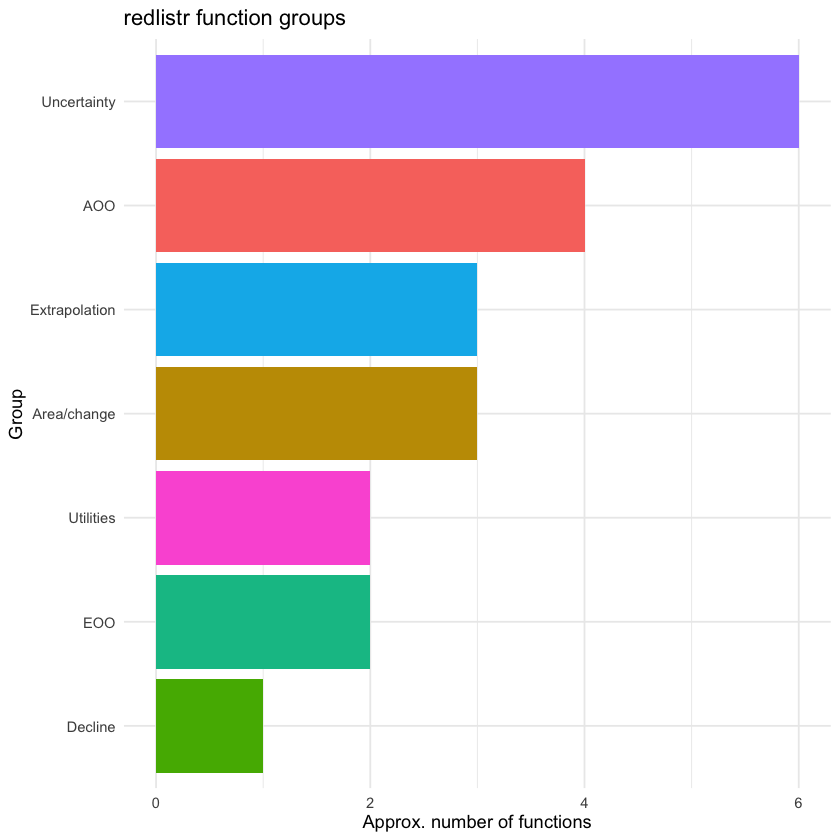

In [119]:
# Build a lightweight function-group map for teaching.
function_groups <- data.frame(
  group = c("AOO", "EOO", "Area/change", "Decline", "Uncertainty", "Extrapolation", "Utilities"),
  n_functions = c(4, 2, 3, 1, 6, 3, 2),
  stringsAsFactors = FALSE
)

ggplot(function_groups, aes(x = reorder(group, n_functions), y = n_functions, fill = group)) +
  geom_col(show.legend = FALSE) +
  coord_flip() +
  labs(title = "redlistr function groups", x = "Group", y = "Approx. number of functions") +
  theme_minimal()


## 5) Reef ecosystem demo data (synthetic, no external files)

We create two small rasters representing Reef habitat at two time points.

In [120]:
# Reproducible seed for deterministic demo
set.seed(42)

# Output data directory
dir.create("data", showWarnings = FALSE)
reef_sample_path <- file.path("data", "reef_sample.tif")

# Load sample raster from `raster` package if demo file doesn't exist.
# This provides a real but lightweight example without external downloads.
if (!file.exists(reef_sample_path)) {
  try(
    {
      sample_r <- raster::raster(system.file("external/test.grd", package = "raster"))
      raster::writeRaster(sample_r, reef_sample_path, overwrite = TRUE)
      message("Wrote example raster from raster::test.grd to ", reef_sample_path)
    },
    silent = TRUE
  )
}

# Try loading the sample raster as a terra::SpatRaster
reef_2000_spat <- try(terra::rast(reef_sample_path), silent = TRUE)
if (inherits(reef_2000_spat, "try-error")) {
  message("Failed to read sample raster; generating synthetic data.")
  reef_2000_spat <- NULL
}

# If no raster exists, create synthetic occupancy maps (1 = occupied, NA = unoccupied)
if (is.null(reef_2000_spat)) {
  reef_crs <- "EPSG:32755"
  reef_mat <- matrix(sample(c(NA, 1), 600, replace = TRUE, prob = c(0.55, 0.45)), nrow = 30, ncol = 20)
  reef_2000_spat <- terra::rast(reef_mat, crs = reef_crs)
  terra::ext(reef_2000_spat) <- c(0, 6000, 0, 9000)
  message("Generated synthetic reef_2000 raster (30 x 20 cells).")
}

# Create 2020 raster by perturbing the 2000 raster (~10% of occupied cells become unoccupied)
reef_2020_spat <- reef_2000_spat
vals <- terra::values(reef_2020_spat)
idx <- which(vals == 1)
nflip <- floor(length(idx) * 0.1)
if (nflip > 0) vals[sample(idx, nflip)] <- NA
terra::values(reef_2020_spat) <- vals
message("Created 2020 raster by perturbing sample (simulating 10% habitat loss).")

# Save sample TIFF
try(terra::writeRaster(reef_2000_spat, reef_sample_path, overwrite = TRUE), silent = TRUE)

# Convert to RasterLayer for redlistr compatibility
# (redlistr was designed for raster::RasterLayer, not terra::SpatRaster)
reef_2000_raster <- raster::raster(reef_sample_path)
reef_2020_raster <- raster::raster(reef_2000_raster) # Start from 2000
vals_2020 <- values(reef_2020_raster)
idx_2020 <- which(vals_2020 == 1)
nflip_2020 <- floor(length(idx_2020) * 0.1)
if (nflip_2020 > 0) vals_2020[sample(idx_2020, nflip_2020)] <- NA
values(reef_2020_raster) <- vals_2020


Created 2020 raster by perturbing sample (simulating 10% habitat loss).



In [122]:
# Set reproducible random seed
set.seed(42)

# Output data directory
dir.create("data", showWarnings = FALSE)
reef_sample_path <- file.path("data", "reef_sample.tif")

# Load sample raster from `raster` package if demo file doesn't exist.
# This provides a real but lightweight example without external downloads.
if (!file.exists(reef_sample_path)) {
    try(
        {
            sample_r <- raster::raster(system.file("external/test.grd", package = "raster"))
            raster::writeRaster(sample_r, reef_sample_path, overwrite = TRUE)
            message("Wrote example raster from raster::test.grd to ", reef_sample_path)
        },
        silent = TRUE
    )
}

# Try loading the sample raster as a terra::SpatRaster
reef_2000_spat <- try(terra::rast(reef_sample_path), silent = TRUE)
if (inherits(reef_2000_spat, "try-error")) {
    message("Failed to read sample raster; generating synthetic data.")
    reef_2000_spat <- NULL
}

# If no raster exists, create synthetic occupancy maps (1 = occupied, NA = unoccupied)
if (is.null(reef_2000_spat)) {
    reef_crs <- "EPSG:32755"
    reef_mat <- matrix(sample(c(NA, 1), 600, replace = TRUE, prob = c(0.55, 0.45)), nrow = 30, ncol = 20)
    reef_2000_spat <- terra::rast(reef_mat, crs = reef_crs)
    terra::ext(reef_2000_spat) <- c(0, 6000, 0, 9000)
    message("Generated synthetic reef_2000 raster (30 x 20 cells).")
}

# Create 2020 raster by perturbing the 2000 raster (~10% of occupied cells become unoccupied)
reef_2020_spat <- reef_2000_spat
vals <- terra::values(reef_2020_spat)
idx <- which(vals == 1)
nflip <- floor(length(idx) * 0.1)
if (nflip > 0) vals[sample(idx, nflip)] <- NA
terra::values(reef_2020_spat) <- vals
message("Created 2020 raster by perturbing sample (simulating 10% habitat loss).")

# Save sample TIFF
try(terra::writeRaster(reef_2000_spat, reef_sample_path, overwrite = TRUE), silent = TRUE)

# Convert to RasterLayer for redlistr compatibility
# (redlistr was designed for raster::RasterLayer, not terra::SpatRaster)
reef_2000_raster <- raster::raster(reef_sample_path)
reef_2020_raster <- raster::raster(reef_2000_raster)
vals_2020 <- raster::values(reef_2020_raster)
idx_2020 <- which(vals_2020 == 1)
nflip_2020 <- floor(length(idx_2020) * 0.1)
if (nflip_2020 > 0) vals_2020[sample(idx_2020, nflip_2020)] <- NA
raster::values(reef_2020_raster) <- vals_2020

# Quick inspection
reef_2000_raster


ERROR: Error in parse(text = input): attempt to use zero-length variable name


In [ ]:
# === AOO (Area of Occupancy) ===
# See: https://cran.r-project.org/web/packages/redlistr/index.html
# Reference: https://www.iucn.org/resources/categories-and-criteria
#
# AOO quantifies occupied habitat using grid cell analysis.
# Requires RasterLayer dispatch; SpatRaster will fail.

# Safe wrapper for error handling
safe_run <- function(expr, label) {
  tryCatch(
    {
      val <- eval(expr)
      message("[OK] ", label)
      print(val)
      invisible(val)
    },
    error = function(e) {
      message("[ERROR] ", label, ": ", e$message)
      invisible(NULL)
    }
  )
}

# Compute AOO using 1 km grid cells with minimum 1% occupancy rule
reef_aoo_2000 <- safe_run(
  quote(getAOO(reef_2000_raster, grid.size = 1000, min.percent.rule = TRUE, percent = 1)),
  "getAOO (RasterLayer)"
)

# Generate AOO grid geometry
reef_aoo_grid <- safe_run(
  quote(makeAOOGrid(reef_2000_raster, grid.size = 1000, min.percent.rule = TRUE, percent = 1)),
  "makeAOOGrid (RasterLayer)"
)


ERROR: Error in UseMethod("makeAOOGrid", input.data): no applicable method for 'makeAOOGrid' applied to an object of class "SpatRaster"


## 7) Group B: EOO (Extent of Occurrence)

EOO captures overall distribution extent (often via convex hull-style geometry).

In [ ]:
# === EOO (Extent of Occurrence) ===
# See: https://cran.r-project.org/web/packages/redlistr/index.html
#
# EOO captures overall distribution extent using convex hull or similar geometry.
# Represents the geographic spread of occupied cells.

# Create EOO polygon
reef_eoo_poly <- safe_run(
  quote(makeEOO(reef_2000_raster)),
  "makeEOO"
)

# Get EOO area (if polygon was created)
if (!is.null(reef_eoo_poly)) {
  reef_eoo_area <- safe_run(
    quote(getAreaEOO(reef_eoo_poly)),
    "getAreaEOO"
  )
} else {
  message("EOO polygon not available.")
  reef_eoo_area <- NA
}


 class       : SpatVector 
 geometry    : polygons 
 dimensions  : 1, 0  (geometries, attributes)
 extent      : 0, 6000, 0, 9000  (xmin, xmax, ymin, ymax)
 coord. ref. : WGS 84 / UTM zone 55S (EPSG:32755) 

[1] 53.43474

## 8) Group C: Area and change metrics

Compare total occupied area between two time points.

In [ ]:
# Area at each time point.
reef_area_2000 <- getArea(reef_2000_raster)
reef_area_2020 <- getArea(reef_2020_raster)

# Net area loss (function available in current redlistr)
reef_area_change <- safe_run(
    quote(getAreaLoss(reef_2000_raster, reef_2020_raster)),
    "getAreaLoss"
)

reef_area_2000
reef_area_2020
reef_area_change


ERROR: Error in (function (cond) : error in evaluating the argument 'x' in selecting a method for function 'isTRUE': argument "byValue" is missing, with no default


## 9) Group D: Decline statistics

Summarize decline rate and proportional decline from area estimates.

In [ ]:
# === Decline Statistics ===
# See: https://cran.r-project.org/web/packages/redlistr/index.html
#
# Compute multiple decline rates (ARD, PRD, ARC):
# - ARD: Absolute Rate of Decline (% per year)
# - PRD: Proportional Rate of Decline
# - ARC: Annual Rate of Change
#
# Reference: IUCN Red List guidelines
# https://www.iucn.org/resources/categories-and-criteria

# Convert area outputs to numeric for decline function
a_t1 <- as.numeric(reef_area_2000)
a_t2 <- as.numeric(reef_area_2020)

if (!is.na(a_t1) && !is.na(a_t2)) {
  reef_decline <- safe_run(
    quote(getDeclineStats(
      A.t1 = a_t1,
      A.t2 = a_t2,
      year.t1 = 2000,
      year.t2 = 2020,
      methods = c("ARD", "PRD", "ARC")
    )),
    "getDeclineStats"
  )
} else {
  message("Area values missing; skipping decline calculation.")
}


ERROR: Error: object 'reef_area_2000' not found


## 10) Group E: Grid uncertainty

Test how AOO can vary with different grid placements (small simulation for class speed).

## 10) Visualization: Area trend over time


In [ ]:
# Create a simple area-over-time plot
# Extract numeric area values (handle NA gracefully)
a_2000_num <- tryCatch(as.numeric(reef_area_2000), error = function(e) NA)
a_2020_num <- tryCatch(as.numeric(reef_area_2020), error = function(e) NA)

if (!is.na(a_2000_num) && !is.na(a_2020_num)) {
  # Build trend data
  reef_trend_df <- data.frame(
    year = c(2000, 2020),
    area_km2 = c(a_2000_num, a_2020_num)
  )

  # Plot with ggplot2
  trend_plot <- ggplot(reef_trend_df, aes(x = year, y = area_km2)) +
    geom_line(size = 1, color = "steelblue") +
    geom_point(size = 3, color = "steelblue") +
    labs(
      title = "Reef Habitat Area Trend (2000–2020)",
      x = "Year",
      y = "Area (km²)"
    ) +
    theme_minimal() +
    theme(plot.title = element_text(face = "bold", size = 12))

  print(trend_plot)
} else {
  message("Area values not available for plotting.")
}


In [ ]:
# Run a short uncertainty simulation (5 replicates for demo speed).
reef_uncertainty <- tryCatch(
  gridUncertaintySimulation(
    input.data = reef_2000,
    grid.size = 1000,
    simulations = 5,
    min.percent.rule = FALSE,
    percent = 1
  ),
  error = function(e) {
    message("gridUncertaintySimulation not available for this input class in current redlistr version.")
    NULL
  }
)

reef_uncertainty


gridUncertaintySimulation not available for this input class in current redlistr version.



NULL

## 11) Group F: Extrapolation tools

Use help pages to inspect arguments in your installed version.

In [ ]:
# Open built-in docs for extrapolation-related functions.
help("extrapolate", package = "redlistr")
help("futureAreaEstimate", package = "redlistr")
help("sequentialExtrapolate", package = "redlistr")


No documentation for ‘extrapolate’ in specified packages and libraries:
you could try ‘??extrapolate’

futureAreaEstimate          package:redlistr           R Documentation

_F_u_t_u_r_e _A_r_e_a _E_s_t_i_m_a_t_e

_D_e_s_c_r_i_p_t_i_o_n:

     ‘futureAreaEstimate’ is now deprecated, please use
     ‘extrapolateEstimate’ instead

_U_s_a_g_e:

     futureAreaEstimate(A.t1, year.t1, nYears, ARD = NA, PRD = NA, ARC = NA)
     
_A_r_g_u_m_e_n_t_s:

    A.t1: Area at time t1

 year.t1: Year of time t1

  nYears: Number of years since t1 for area prediction

     ARD: Absolute rate of decline

     PRD: Proportional rate of decline

     ARC: Annual rate of change

_V_a_l_u_e:

     A dataframe with the forecast year, and a combination of:

        • Future area as estimated with absolute rate of decline (ARD)

        • Future area as estimated with proportional rate of decline
          (PRD)

        • Future area as estimated with annual rate of change (ARC)

_A_u_t_h_o_r(_s):

     Nicholas Murray <mailto:murr.nick@gmail.com>, Calvin

sequentialExtrapolate         package:redlistr         R Documentation

_S_e_q_u_e_n_t_i_a_l _e_x_t_r_a_p_o_l_a_t_i_o_n _e_s_t_i_m_a_t_e

_D_e_s_c_r_i_p_t_i_o_n:

     ‘sequentialExtrapolate’ uses rates of decline from getDeclineStats
     and generates a sequence of estimates at regular time-steps.
     Useful for generating a sequence for plotting graphs.

_U_s_a_g_e:

     sequentialExtrapolate(A.t1, year.t1, nYears, ARD = NA, PRD = NA, ARC = NA)
     
_A_r_g_u_m_e_n_t_s:

    A.t1: Area at time t1

 year.t1: Year of time t1

  nYears: Number of years since t1 for prediction. Use negative values
          for backcasting

     ARD: Absolute rate of decline

     PRD: Proportional rate of decline

     ARC: Annual rate of change

_V_a_l_u_e:

     A dataframe with the forecast year, and a combination of:

        • Sequence of values as extrapolated with absolute rate of
          decline (ARD)

        • Sequence of values

## 12) Visual communication example (ggplot2)

Plot Reef area trend for reporting and teaching.

In [ ]:
# === Grid uncertainty extension ===
# redlistr offers `gridUncertainty` (metric summary) and
# `gridUncertaintyRandom` (Monte Carlo randomization).
# We'll demonstrate the simple summary function here; it requires
# the number of grid improvements to attempt (`n.AOO.improvement`).

reef_uncertainty <- safe_run(
  quote(gridUncertainty(input.data = reef_2000_raster, grid.size = 1000, n.AOO.improvement = 10)),
  "gridUncertainty"
)


ERROR: Error: object 'reef_area_2000' not found


## 13) Quick checklist

1. Prepare/validate spatial inputs and CRS.
2. Compute AOO and EOO.
3. Estimate area change and decline statistics.
4. Run uncertainty checks.
5. Document assumptions and cite methods.

## 14) Troubleshooting

- If `redlistr` install fails, verify CRAN connectivity and library write permissions.
- If API check fails, confirm `IUCN_REDLIST_KEY` exists in `.env` or `.Renviron`.
- If spatial results look wrong, verify grid size units and CRS.